In [ ]:
import gdelt
import pandas as pd
import numpy as np
import datetime as dt
import matplotlib.pyplot as plt

gd2 = gdelt.gdelt(version=2)

gkg = gd2.Search(["2025 Dec 19"], table="gkg", coverage=True, output="pandas")
print(gkg.shape)
print(gkg.columns)
gkg.head()

(4175, 27)
Index(['GKGRECORDID', 'DATE', 'SourceCollectionIdentifier', 'SourceCommonName',
       'DocumentIdentifier', 'Counts', 'V2Counts', 'Themes', 'V2Themes',
       'Locations', 'V2Locations', 'Persons', 'V2Persons', 'Organizations',
       'V2Organizations', 'V2Tone', 'Dates', 'GCAM', 'SharingImage',
       'RelatedImages', 'SocialImageEmbeds', 'SocialVideoEmbeds', 'Quotations',
       'AllNames', 'Amounts', 'TranslationInfo', 'Extras'],
      dtype='object')


,GKGRECORDID,DATE,SourceCollectionIdentifier,SourceCommonName,DocumentIdentifier,Counts,V2Counts,Themes,V2Themes,Locations,...,GCAM,SharingImage,RelatedImages,SocialImageEmbeds,SocialVideoEmbeds,Quotations,AllNames,Amounts,TranslationInfo,Extras
0,20251219000000-0,20251219000000,1,comoxvalleyrecord.com,https://comoxvalleyrecord.com/2025/12/18/quesn...,NaN,NaN,UNGP_FORESTS_RIVERS_OCEANS;WB_135_TRANSPORT;WB...,"TAX_ECON_PRICE,1241;TAX_ECON_PRICE,3061;TAX_EC...","4#Vancouver, British Columbia, Canada#CA#CA02#...",...,"wc:1175,c12.1:65,c12.10:126,c12.12:24,c12.13:5...",https://comoxvalleyrecord.com/wp-content/uploa...,NaN,NaN,NaN,5876|54||big thing for our community with the ...,"North Vancouver,83;Prince George,101;Northern ...","5,months,1019;105,dollars ,1032;105,dollars ,1...",NaN,<PAGE_AUTHORS>none</PAGE_AUTHORS><PAGE_PRECISE...
1,20251219000000-1,20251219000000,1,deseret.com,https://www.deseret.com/u-s-world/2025/12/18/i...,"KILL#2#students#3#Brown University, Rhode Isla...","KILL#2#students#3#Brown University, Rhode Isla...",CRISISLEX_C07_SAFETY;EDUCATION;SOC_POINTSOFINT...,"TAX_WORLDLANGUAGES_MASSACHUSETTS,176;TAX_WORLD...","2#Rhode Island, United States#US#USRI#41.6772#...",...,"wc:268,c12.1:11,c12.10:15,c12.12:9,c12.13:1,c1...",https://www.deseret.com/resizer/v2/NACCXETSJBH...,NaN,NaN,https://youtube.com/channel/UCP7SfUaCqZNYBwM6o...,NaN,"Brown University,77;New York,528;Rhode Island,...","45,miles,593;2,students were killed,622;50,dol...",NaN,<PAGE_LINKS>https://www.cbsnews.com/amp/news/p...
2,20251219000000-2,20251219000000,1,ktvz.com,https://ktvz.com/politics/cnn-us-politics/2025...,NaN,NaN,LEADER;TAX_FNCACT;TAX_FNCACT_PRESIDENT;TAX_FNC...,"GENERAL_HEALTH,225;GENERAL_HEALTH,344;GENERAL_...","3#White House, District Of Columbia, United St...",...,"wc:1369,c1.2:12,c12.1:84,c12.10:137,c12.12:37,...",https://ktvz.b-cdn.net/2025/12/cnn-L19jb21wb25...,NaN,NaN,NaN,1922|74||update the statutory definition of fi...,"Kit Maher,13;Steve Contorno,33;Sarah Owermohle...","1,drug,759;3,drug,931;4,milligrams of THC per,...",NaN,<PAGE_LINKS>https://www.cnn.com/2023/10/02/inv...
3,20251219000000-3,20251219000000,1,miragenews.com,https://www.miragenews.com/construction-comple...,NaN,NaN,CRISISLEX_C03_WELLBEING_HEALTH;GENERAL_GOVERNM...,"ALLIANCE,1285;LEADER,1642;TAX_FNCACT_MAYOR,164...",NaN,...,"wc:401,c1.1:1,c12.1:27,c12.10:41,c12.12:11,c12...",https://www.mornpen.vic.gov.au/files/assets/pu...,NaN,NaN,NaN,NaN,"Rye Township Plan,134;Rye Foreshore Park,348;N...","1,of the Rye Township,88;2,plaza areas on eith...",NaN,<PAGE_LINKS>https://www.miragenews.com/constru...
4,20251219000000-4,20251219000000,1,accountingtoday.com,https://www.accountingtoday.com/news/sorren-ad...,NaN,NaN,UNGP_FORESTS_RIVERS_OCEANS;GENERAL_HEALTH;MEDI...,"LEADER,1424;TAX_FNCACT_PRESIDENT,1424;USPEC_PO...","2#Idaho, United States#US#USID#44.2394#-114.51...",...,"wc:241,c12.1:21,c12.10:18,c12.12:1,c12.13:7,c1...",https://source-media-brightspot.s3.us-east-1.a...,NaN,NaN,NaN,NaN,"Casey Neilon,69;Carson City,269;Casey Neilon,4...","33,professional staff,275;6,partners,320;100,p...",NaN,<PAGE_LINKS>https://www.accountingtoday.com/li...


In [37]:
def parse_tone_bundle(v, k=7):
    """Parse comma-separated tone bundle into floats; pad/NaN on errors."""
    if not isinstance(v, str) or v.strip() == "":
        return [np.nan]*k
    parts = v.split(",")
    parts += [None]*(k - len(parts))
    out = []
    for p in parts[:k]:
        try:
            out.append(float(p))
        except:
            out.append(np.nan)
    return out

tone_col = "V2Tone" if "V2Tone" in gkg.columns else ("Tone" if "Tone" in gkg.columns else None)
if tone_col is None:
    raise KeyError("No V2Tone or Tone column found. Print gkg.columns to inspect.")

tone_cols = ["tone","pos","neg","polarity","activity_ref","self_group_ref","wordcount"]
gkg[tone_cols] = gkg[tone_col].apply(lambda x: pd.Series(parse_tone_bundle(x, k=len(tone_cols))))


In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def ensure_datetime(df):
    if "date_dt" in df.columns:
        return df
    if "DATE" in df.columns:
        df = df.copy()
        df["date_dt"] = pd.to_datetime(df["DATE"], format="%Y%m%d%H%M%S", errors="coerce")
        df = df.dropna(subset=["date_dt"])
        return df
    raise KeyError("Need DATE or date_dt to do time-based EDA.")

def count_list(s, sep=";"):
    if not isinstance(s, str) or s.strip() == "":
        return 0
    return len([x for x in s.split(sep) if x.strip()])

def explode_list_col(df, col, sep=";"):
    """Explode a semicolon-separated list column into long form."""
    if col not in df.columns:
        raise KeyError(f"Missing column: {col}")
    out = df[[c for c in df.columns if c != col]].copy()
    tmp = df[col].fillna("").astype(str).str.split(sep)
    out[col] = tmp
    out = out.explode(col)
    out[col] = out[col].astype(str).str.strip()
    out = out[out[col] != ""]
    return out

gkg = ensure_datetime(gkg)
gkg["day"] = gkg["date_dt"].dt.floor("D")
gkg["hour"] = gkg["date_dt"].dt.hour
gkg["dow"] = gkg["date_dt"].dt.day_name()


In [9]:
miss = (gkg.isna().mean().sort_values(ascending=False) * 100).round(2)
print(miss.head(30))


TranslationInfo               100.00
SocialImageEmbeds              89.21
RelatedImages                  87.57
V2Counts                       87.02
Counts                         87.02
Quotations                     78.40
Dates                          64.99
SocialVideoEmbeds              48.65
V2Organizations                27.55
Amounts                        25.31
V2Locations                    25.19
Locations                      25.04
Organizations                  24.88
V2Persons                      23.22
Persons                        22.38
SharingImage                   13.23
V2Themes                       10.12
Themes                         10.12
AllNames                        4.72
SourceCommonName                0.00
DocumentIdentifier              0.00
DATE                            0.00
GKGRECORDID                     0.00
SourceCollectionIdentifier      0.00
GCAM                            0.00
V2Tone                          0.00
Extras                          0.00
t

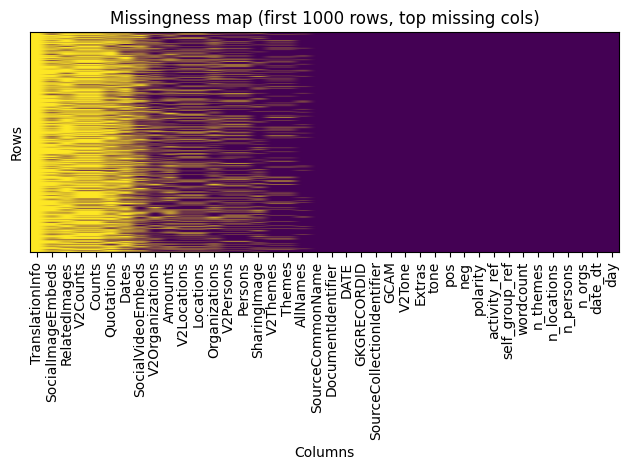

In [10]:
cols = miss.index[:40].tolist()
mat = gkg[cols].isna().astype(int).head(1000).to_numpy()

plt.figure()
plt.imshow(mat, aspect="auto")
plt.title("Missingness map (first 1000 rows, top missing cols)")
plt.xlabel("Columns")
plt.ylabel("Rows")
plt.xticks(range(len(cols)), cols, rotation=90)
plt.yticks([])
plt.tight_layout()
plt.show()


In [11]:
for key in ["GKGRECORDID", "GKGRecordID", "DocumentIdentifier"]:
    if key in gkg.columns:
        dup_rate = gkg.duplicated(subset=[key]).mean()
        print(f"Duplicate rate by {key}: {dup_rate:.3%}")


Duplicate rate by GKGRECORDID: 0.000%
Duplicate rate by DocumentIdentifier: 0.000%


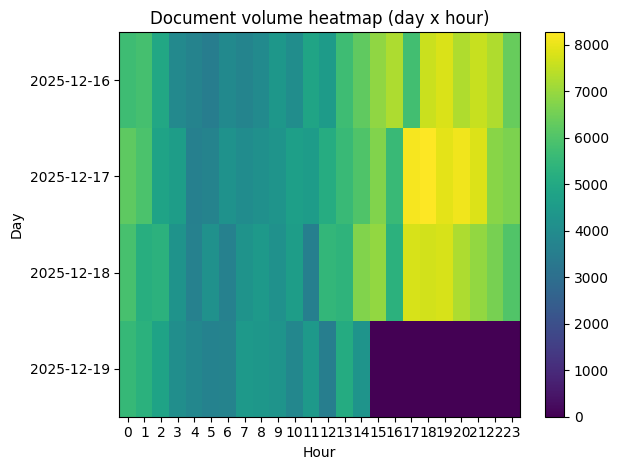

In [12]:
vol = (gkg.groupby(["day","hour"]).size().unstack(fill_value=0)).sort_index()

plt.figure()
plt.imshow(vol.to_numpy(), aspect="auto")
plt.title("Document volume heatmap (day x hour)")
plt.xlabel("Hour")
plt.ylabel("Day")
plt.xticks(range(vol.shape[1]), vol.columns)
plt.yticks(range(vol.shape[0]), [d.strftime("%Y-%m-%d") for d in vol.index])
plt.colorbar()
plt.tight_layout()
plt.show()


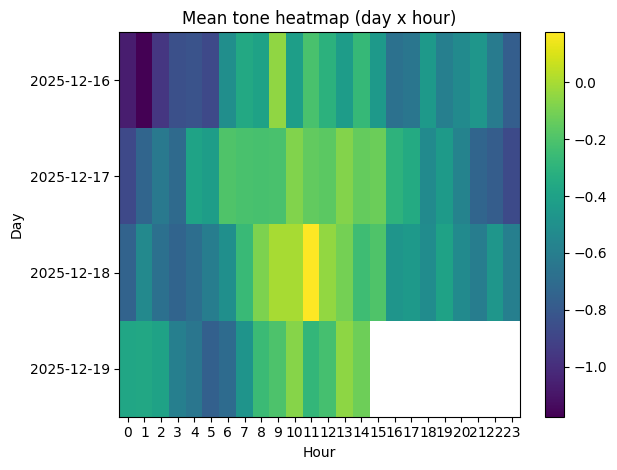

In [13]:
if "tone" in gkg.columns:
    mt = (gkg.groupby(["day","hour"])["tone"].mean().unstack())
    plt.figure()
    plt.imshow(mt.to_numpy(), aspect="auto")
    plt.title("Mean tone heatmap (day x hour)")
    plt.xlabel("Hour")
    plt.ylabel("Day")
    plt.xticks(range(mt.shape[1]), mt.columns)
    plt.yticks(range(mt.shape[0]), [d.strftime("%Y-%m-%d") for d in mt.index])
    plt.colorbar()
    plt.tight_layout()
    plt.show()


tone p01/p99: -11.6838487972509 9.63855421686747


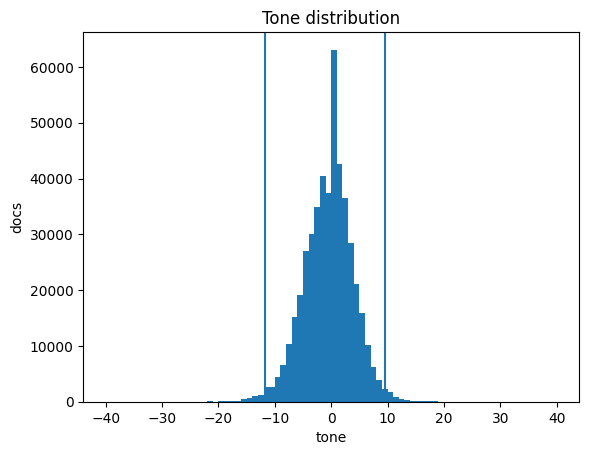

In [14]:
if "tone" in gkg.columns:
    x = gkg["tone"].dropna().astype(float)
    p1, p99 = x.quantile([0.01, 0.99])
    print("tone p01/p99:", float(p1), float(p99))

    plt.figure()
    plt.hist(x, bins=80)
    plt.title("Tone distribution")
    plt.xlabel("tone")
    plt.ylabel("docs")
    plt.axvline(p1)
    plt.axvline(p99)
    plt.show()


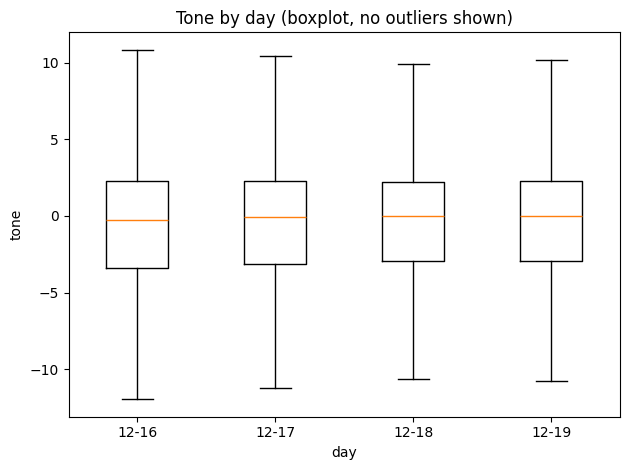

In [33]:
if "tone" in gkg.columns:
    daily = gkg.dropna(subset=["tone"]).copy()
    days = sorted(daily["day"].unique())
    data = [daily.loc[daily["day"]==d, "tone"].astype(float).values for d in days]

    plt.figure()
    plt.boxplot(data, tick_labels=[pd.Timestamp(d).strftime("%m-%d") for d in days], showfliers=False)
    plt.title("Tone by day (boxplot, no outliers shown)")
    plt.xlabel("day")
    plt.ylabel("tone")
    plt.tight_layout()
    plt.show()


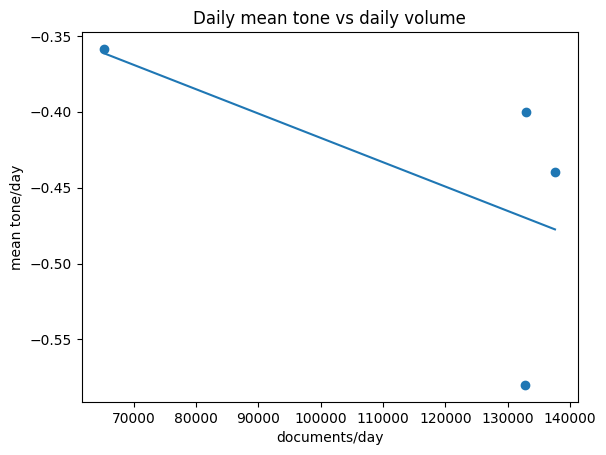

In [16]:
if "tone" in gkg.columns:
    daily = (gkg.groupby("day")
             .agg(documents=("day","size"), mean_tone=("tone","mean"))
             .reset_index())
    x = daily["documents"].to_numpy()
    y = daily["mean_tone"].to_numpy()

    plt.figure()
    plt.scatter(x, y)
    if len(x) >= 2:
        m, b = np.polyfit(x, y, 1)
        xx = np.linspace(x.min(), x.max(), 100)
        plt.plot(xx, m*xx + b)
    plt.title("Daily mean tone vs daily volume")
    plt.xlabel("documents/day")
    plt.ylabel("mean tone/day")
    plt.show()


In [17]:
if "tone" in gkg.columns:
    daily = (gkg.groupby("day")
             .agg(documents=("day","size"), mean_tone=("tone","mean"))
             .sort_index())
    max_lag = 3
    for lag in range(-max_lag, max_lag+1):
        corr = daily["documents"].corr(daily["mean_tone"].shift(lag))
        print(f"corr(documents, mean_tone shifted {lag:+d}d): {corr:.3f}")


corr(documents, mean_tone shifted -3d): nan
corr(documents, mean_tone shifted -2d): 1.000
corr(documents, mean_tone shifted -1d): 0.016
corr(documents, mean_tone shifted +0d): -0.579
corr(documents, mean_tone shifted +1d): -0.712
corr(documents, mean_tone shifted +2d): -1.000
corr(documents, mean_tone shifted +3d): nan


c:\Users\hucu\Desktop\Big-Data-Analytics\venv\Lib\site-packages\numpy\lib\_function_base_impl.py:3057: RuntimeWarning: Degrees of freedom <= 0 for slice
  c = cov(x, y, rowvar, dtype=dtype)
c:\Users\hucu\Desktop\Big-Data-Analytics\venv\Lib\site-packages\numpy\lib\_function_base_impl.py:2914: RuntimeWarning: divide by zero encountered in divide
  c *= np.true_divide(1, fact)
c:\Users\hucu\Desktop\Big-Data-Analytics\venv\Lib\site-packages\numpy\lib\_function_base_impl.py:2914: RuntimeWarning: invalid value encountered in multiply
  c *= np.true_divide(1, fact)


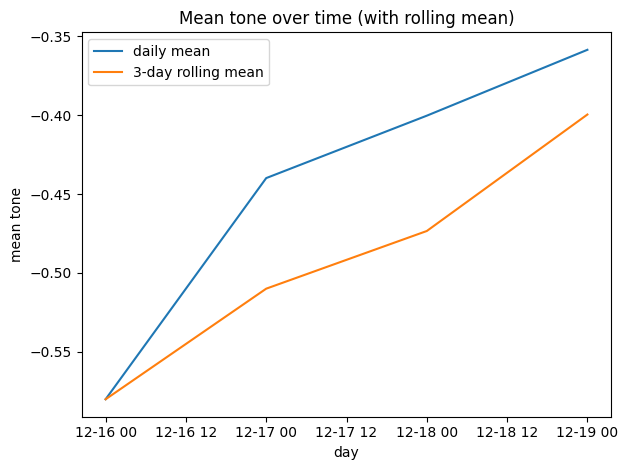

In [18]:
if "tone" in gkg.columns:
    daily = (gkg.groupby("day")["tone"].mean().sort_index())
    roll = daily.rolling(3, min_periods=1)
    plt.figure()
    plt.plot(daily.index, daily.values, label="daily mean")
    plt.plot(roll.mean().index, roll.mean().values, label="3-day rolling mean")
    plt.title("Mean tone over time (with rolling mean)")
    plt.xlabel("day")
    plt.ylabel("mean tone")
    plt.legend()
    plt.tight_layout()
    plt.show()


                      documents  mean_tone
SourceCommonName                          
iheart.com                33335  -1.431371
tvguide.co.uk              6750  -0.477872
yahoo.com                  4965  -0.683031
indiatimes.com             4945  -0.523977
biztoc.com                 4750  -0.989939
el-balad.com               2596   0.300991
manilatimes.net            2545   2.246619
themarketsdaily.com        2165   1.904451
marketscreener.com         2087   0.095564
openpr.com                 1924   2.603368
dailypolitical.com         1832   1.906372
boredpanda.com             1806  -0.933504
miragenews.com             1766   0.332767
finanznachrichten.de       1693   1.846370
tickerreport.com           1677   1.864196
newkerala.com              1653   3.962078
thehindu.com               1578  -1.381378
moneycontrol.com           1565  -0.397800
dailymail.co.uk            1492  -0.477703
indianexpress.com          1410  -1.578043


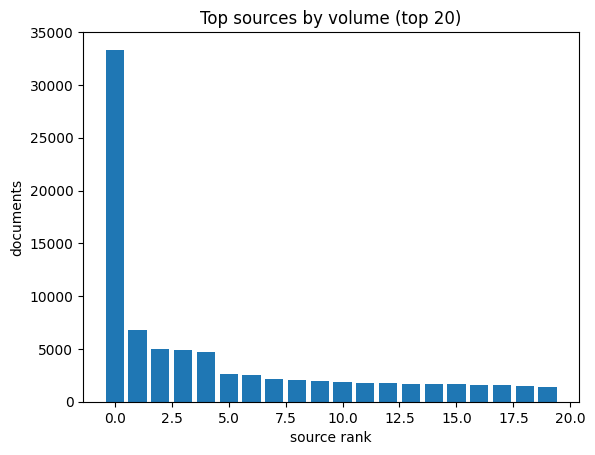

In [19]:
src_col = None
for c in ["SourceCommonName", "sourceCommonName", "Source"]:
    if c in gkg.columns:
        src_col = c
        break

if src_col and "tone" in gkg.columns:
    top = (gkg.groupby(src_col)
           .agg(documents=("tone","size"), mean_tone=("tone","mean"))
           .sort_values("documents", ascending=False)
           .head(20))
    print(top)

    plt.figure()
    plt.bar(range(len(top)), top["documents"].to_numpy())
    plt.title("Top sources by volume (top 20)")
    plt.xlabel("source rank")
    plt.ylabel("documents")
    plt.show()


                                         mentions  mean_tone
Themes                                                      
TAX_FNCACT                                 364236  -0.793249
EPU_POLICY                                 174570  -1.529325
CRISISLEX_CRISISLEXREC                     155884  -2.889232
TAX_ETHNICITY                              144695  -0.772505
UNGP_FORESTS_RIVERS_OCEANS                 135416  -0.207039
WB_696_PUBLIC_SECTOR_MANAGEMENT            129509  -2.097241
USPEC_POLITICS_GENERAL1                    119186  -1.262260
CRISISLEX_C07_SAFETY                       111623  -3.464409
SOC_POINTSOFINTEREST                       110549  -1.963373
LEADER                                     110102  -1.194708
EPU_ECONOMY_HISTORIC                        99586   0.349217
USPEC_POLICY1                               98905  -0.590543
WB_621_HEALTH_NUTRITION_AND_POPULATION      97740  -1.871862
TAX_WORLDLANGUAGES                          95976  -0.791295
GENERAL_HEALTH          

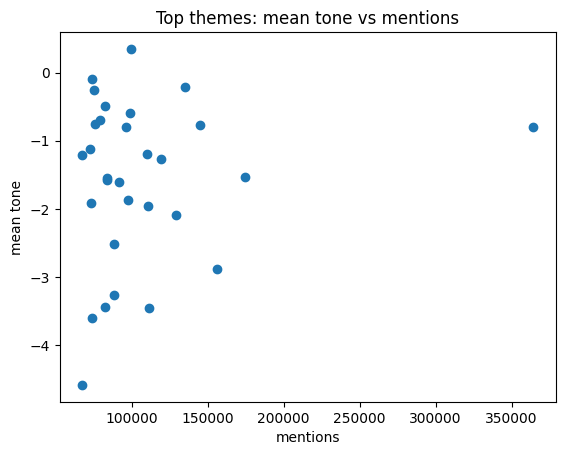

In [20]:
theme_col = "Themes" if "Themes" in gkg.columns else ("V2Themes" if "V2Themes" in gkg.columns else None)

if theme_col and "tone" in gkg.columns:
    long = explode_list_col(gkg[[theme_col, "tone"]].dropna(subset=["tone"]), theme_col)
    theme_stats = (long.groupby(theme_col)
                   .agg(mentions=(theme_col,"size"), mean_tone=("tone","mean"))
                   .sort_values("mentions", ascending=False)
                   .head(30))
    print(theme_stats.head(20))

    plt.figure()
    plt.scatter(theme_stats["mentions"], theme_stats["mean_tone"])
    plt.title("Top themes: mean tone vs mentions")
    plt.xlabel("mentions")
    plt.ylabel("mean tone")
    plt.show()


C:\Users\hucu\AppData\Local\Temp\ipykernel_7620\531718795.py:30: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


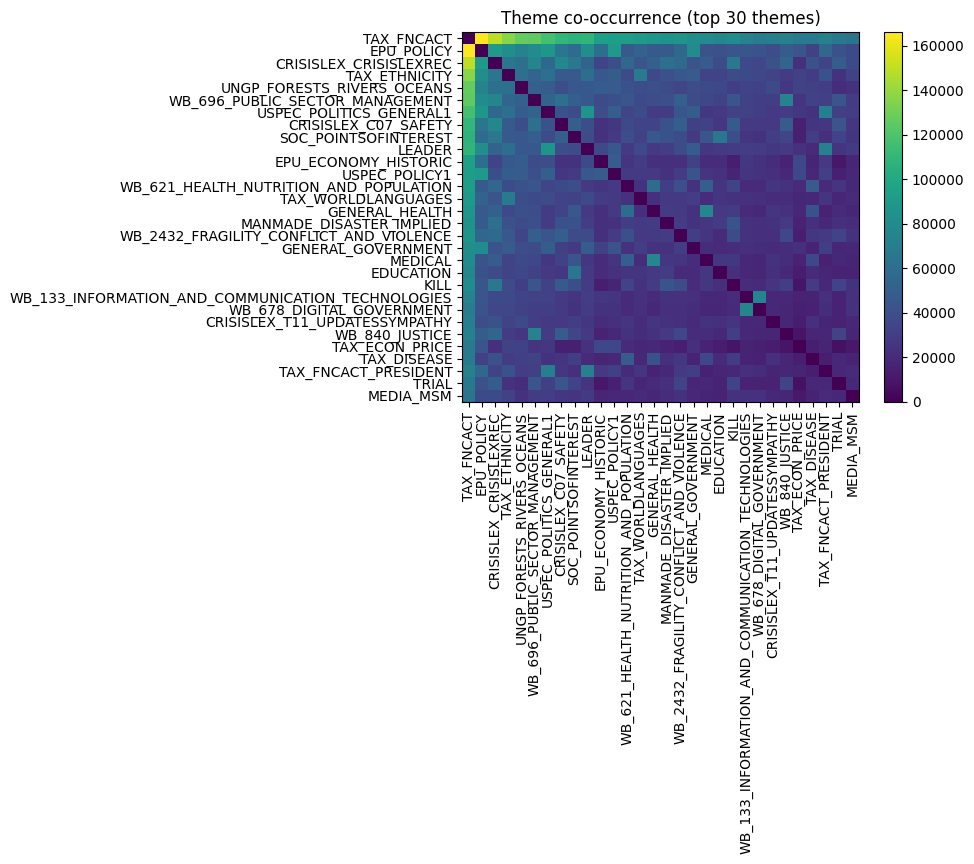

In [21]:
from collections import Counter
import itertools

if theme_col:
    topN = 30
    long = explode_list_col(gkg[[theme_col]].copy(), theme_col)
    top_themes = long[theme_col].value_counts().head(topN).index.tolist()
    top_set = set(top_themes)

    pair_counts = Counter()
    for s in gkg[theme_col].fillna("").astype(str):
        items = [t.strip() for t in s.split(";") if t.strip() in top_set]
        items = sorted(set(items))
        for a, b in itertools.combinations(items, 2):
            pair_counts[(a,b)] += 1

    idx = {t:i for i,t in enumerate(top_themes)}
    M = np.zeros((topN, topN), dtype=int)
    for (a,b), v in pair_counts.items():
        i, j = idx[a], idx[b]
        M[i,j] = v
        M[j,i] = v

    plt.figure()
    plt.imshow(M, aspect="auto")
    plt.title("Theme co-occurrence (top 30 themes)")
    plt.xticks(range(topN), top_themes, rotation=90)
    plt.yticks(range(topN), top_themes)
    plt.colorbar()
    plt.tight_layout()
    plt.show()


Anomalous days (|z|>=2):
Series([], dtype: float64)


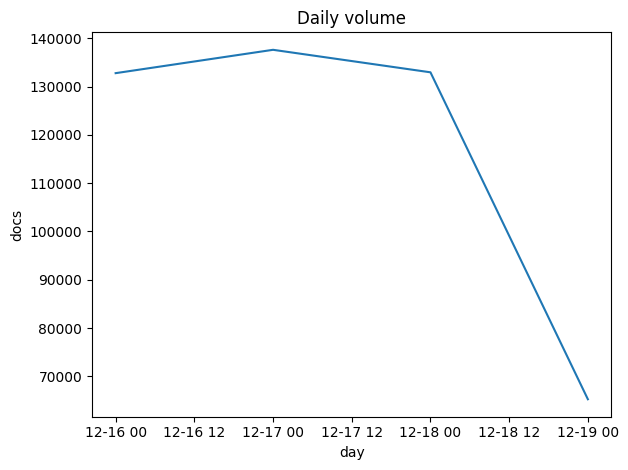

In [22]:
daily_vol = gkg.groupby("day").size().sort_index()
z = (daily_vol - daily_vol.mean()) / (daily_vol.std(ddof=0) + 1e-9)

print("Anomalous days (|z|>=2):")
print(z[abs(z) >= 2].sort_values(ascending=False))

plt.figure()
plt.plot(daily_vol.index, daily_vol.values)
plt.title("Daily volume")
plt.xlabel("day")
plt.ylabel("docs")
plt.tight_layout()
plt.show()


In [23]:
if "tone" in gkg.columns:
    daily_tone = gkg.groupby("day")["tone"].mean().sort_index()
    zt = (daily_tone - daily_tone.mean()) / (daily_tone.std(ddof=0) + 1e-9)
    print("Tone shock days (|z|>=2):")
    print(zt[abs(zt) >= 2].sort_values(ascending=False))


Tone shock days (|z|>=2):
Series([], Name: tone, dtype: float64)


# Top N entities by mention volume

In [24]:
from collections import Counter

def extract_names(series, sep=";"):
    c = Counter()
    for s in series.dropna().astype(str):
        for item in s.split(sep):
            item = item.strip()
            if not item:
                continue
            name = item.split(",")[0].strip()
            if name:
                c[name] += 1
    return c

entity_source_col = None
for col in ["Persons", "Organizations", "AllNames", "V2Persons", "V2Organizations"]:
    if col in gkg.columns:
        entity_source_col = col
        break

counts = extract_names(gkg[entity_source_col])
top_entities = [e for e,_ in counts.most_common(50)]
top_entities[:50], len(top_entities)


(['donald trump',
  'los angeles',
  'rob reiner',
  'nick reiner',
  'michele reiner',
  'joe biden',
  'carl reiner',
  'anthony albanese',
  'sajid akram',
  'naveed akram',
  'alan jackson',
  'estelle reiner',
  'conan obrien',
  'las vegas',
  'jeffrey epstein',
  'keir starmer',
  'vladimir putin',
  'billy crystal',
  'barack obama',
  'eli schlanger',
  'karoline leavitt',
  'pete hegseth',
  'nathan hochman',
  'pam bondi',
  'ella cook',
  'narendra modi',
  'ahmed al ahmed',
  'charlie kirk',
  'chris minns',
  'peter neronha',
  'elon musk',
  'mike johnson',
  'marco rubio',
  'mal lanyon',
  'penny marshall',
  'bill clinton',
  'taylor swift',
  'santa claus',
  'jared kushner',
  'scott bessent',
  'friedrich merz',
  'larry david',
  'krissy barrett',
  'robert f kennedy jr',
  'abu dhabi',
  'lok sabha',
  'oscar perez',
  'mukhammad aziz umurzokov',
  'brett smiley',
  'martin short'],
 50)

In [25]:
import requests
import time

SESSION = requests.Session()
SESSION.headers.update({
    "User-Agent": "GDELT-WikiEdits-Correlation/0.1 (student project; contact: 01171199@pw.edu.pl)"
})

def wiki_search_title(query, wiki="en.wikipedia.org", sleep_s=0.2):
    url = f"https://{wiki}/w/api.php"
    params = {
        "action": "query",
        "format": "json",
        "list": "search",
        "srsearch": query,
        "srlimit": 1
    }
    r = SESSION.get(url, params=params, timeout=30)
    if r.status_code == 429:
        time.sleep(2)
        r = SESSION.get(url, params=params, timeout=30)

    r.raise_for_status()
    hits = r.json().get("query", {}).get("search", [])
    time.sleep(sleep_s)
    return hits[0]["title"] if hits else None


entity_to_title = {}
for e in top_entities:
    title = wiki_search_title(e)
    if title:
        entity_to_title[e] = title

list(entity_to_title.items())[:10], len(entity_to_title)


([('donald trump', 'Donald Trump'),
  ('los angeles', 'Los Angeles'),
  ('rob reiner', 'Rob Reiner'),
  ('nick reiner', 'Rob Reiner'),
  ('michele reiner', 'Rob Reiner'),
  ('joe biden', 'Joe Biden'),
  ('carl reiner', 'Carl Reiner'),
  ('anthony albanese', 'Anthony Albanese'),
  ('sajid akram', 'List of terrorist incidents in 2025'),
  ('naveed akram', 'Naveed Akram')],
 50)

In [26]:
import time
import requests
import pandas as pd

SESSION = requests.Session()
SESSION.headers.update({
    "User-Agent": "GDELT-WikiEdits-Correlation/0.1 (student project; contact: 01171199@pw.edu.pl)",
    "Accept": "application/json"
})

def fetch_page_revisions(title, start_iso, end_iso, wiki="en.wikipedia.org", sleep_s=0.15, max_pages=200):
    """
    Fetch revisions for a page between [start_iso, end_iso] inclusive-ish.
    start_iso/end_iso like '2025-12-11T00:00:00Z'
    Returns DataFrame(title, timestamp, user)
    """
    url = f"https://{wiki}/w/api.php"
    params = {
        "action": "query",
        "format": "json",
        "prop": "revisions",
        "titles": title,
        "rvprop": "timestamp|user",
        "rvstart": start_iso,
        "rvend": end_iso,
        "rvdir": "newer",
        "rvlimit": "max",
        "redirects": 1
    }

    rows = []
    for _ in range(max_pages):
        for attempt in range(5):
            r = SESSION.get(url, params=params, timeout=60)
            if r.status_code in (429, 503):
                time.sleep(2 * (attempt + 1))
                continue
            r.raise_for_status()
            break

        js = r.json()
        pages = js.get("query", {}).get("pages", {})
        if not pages:
            break

        page = next(iter(pages.values()))
        if "missing" in page:
            break

        revs = page.get("revisions", [])
        for rv in revs:
            rows.append({
                "title": title,
                "timestamp": rv.get("timestamp"),
                "user": rv.get("user")
            })

        cont = js.get("continue")
        if not cont:
            break
        params.update(cont)

        time.sleep(sleep_s)

    return pd.DataFrame(rows)


start_iso = "2025-12-16T00:00:00Z"
end_iso   = "2025-12-19T15:00:00Z"

wiki_rows = []
for e, title in entity_to_title.items():
    df_r = fetch_page_revisions(title, start_iso, end_iso)
    if not df_r.empty:
        df_r["entity"] = e
        wiki_rows.append(df_r)

wiki_edits = pd.concat(wiki_rows, ignore_index=True) if wiki_rows else pd.DataFrame()
print(wiki_edits.shape)
wiki_edits.head()



(2037, 4)


,title,timestamp,user,entity
0,Donald Trump,2025-12-16T01:09:25Z,Bill Williams,donald trump
1,Donald Trump,2025-12-16T01:24:08Z,DocZach,donald trump
2,Donald Trump,2025-12-16T01:31:54Z,DocZach,donald trump
3,Donald Trump,2025-12-16T01:54:40Z,Bill Williams,donald trump
4,Donald Trump,2025-12-16T01:57:21Z,Bill Williams,donald trump


In [ ]:
wiki_edits["timestamp"] = pd.to_datetime(wiki_edits["timestamp"], utc=True, errors="coerce")
wiki_edits = wiki_edits.dropna(subset=["timestamp"])
wiki_edits["window"] = wiki_edits["timestamp"].dt.floor("h")

y = (wiki_edits.groupby(["entity", "title", "window"])
     .agg(edits=("window","size"), editors=("user", pd.Series.nunique))
     .reset_index())
y.head()


C:\Users\hucu\AppData\Local\Temp\ipykernel_7620\705118604.py:3: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  wiki_edits["window"] = wiki_edits["timestamp"].dt.floor("H")


,entity,title,window,edits,editors
0,ahmed al ahmed,Ahmed Al Ahmed,2025-12-16 10:00:00+00:00,2,2
1,ahmed al ahmed,Ahmed Al Ahmed,2025-12-16 14:00:00+00:00,2,2
2,ahmed al ahmed,Ahmed Al Ahmed,2025-12-17 14:00:00+00:00,1,1
3,ahmed al ahmed,Ahmed Al Ahmed,2025-12-17 16:00:00+00:00,1,1
4,anthony albanese,Anthony Albanese,2025-12-16 03:00:00+00:00,2,2


In [ ]:
def mentions_entity(cell, entity, sep=";"):
    if not isinstance(cell, str) or not cell:
        return False
    items = [x.strip() for x in cell.split(sep) if x.strip()]
    return any(x.split(",")[0].strip() == entity for x in items)

gkg = gkg.copy()
gkg["date_dt"] = pd.to_datetime(gkg["DATE"], format="%Y%m%d%H%M%S", errors="coerce", utc=True)
gkg = gkg.dropna(subset=["date_dt"])
gkg["window"] = gkg["date_dt"].dt.floor("h")



C:\Users\hucu\AppData\Local\Temp\ipykernel_7620\3382299544.py:10: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  gkg["window"] = gkg["date_dt"].dt.floor("H")


In [29]:
feat_rows = []
src = entity_source_col

for e in entity_to_title.keys():
    mask = gkg[src].fillna("").astype(str).apply(lambda s: mentions_entity(s, e))
    sub = gkg.loc[mask].copy()
    if sub.empty:
        continue

    f = (sub.groupby("window")
         .agg(
             gkg_docs=("window","size"),
             mean_tone=("tone","mean"),
             std_tone=("tone","std"),
             neg_share=("tone", lambda s: (s < -2).mean()),
             pos_share=("tone", lambda s: (s >  2).mean()),
             mean_wordcount=("wordcount","mean"),
         )
         .reset_index())
    f["entity"] = e
    feat_rows.append(f)

X = pd.concat(feat_rows, ignore_index=True) if feat_rows else pd.DataFrame()
X.head(), X.shape


(                     window  gkg_docs  mean_tone  std_tone  neg_share  \
 0 2025-12-16 00:00:00+00:00       470  -2.454950  3.209375   0.506383   
 1 2025-12-16 01:00:00+00:00       462  -2.974933  3.109020   0.569264   
 2 2025-12-16 02:00:00+00:00       395  -3.357299  3.400637   0.605063   
 3 2025-12-16 03:00:00+00:00       344  -3.336639  3.370421   0.622093   
 4 2025-12-16 04:00:00+00:00       331  -3.948391  3.361506   0.682779   
 
    pos_share  mean_wordcount        entity  
 0   0.044681      584.523404  donald trump  
 1   0.023810      709.205628  donald trump  
 2   0.037975      586.450633  donald trump  
 3   0.040698      558.479651  donald trump  
 4   0.021148      542.450151  donald trump  ,
 (4130, 8))

In [30]:
data = (y.merge(X, on=["entity","window"], how="inner")
          .sort_values(["entity","window"])
          .reset_index(drop=True))

data["edits_tplus1"] = data.groupby("entity")["edits"].shift(-1)
data = data.dropna(subset=["edits_tplus1"])
data.head()


,entity,title,window,edits,editors,gkg_docs,mean_tone,std_tone,neg_share,pos_share,mean_wordcount,edits_tplus1
0,ahmed al ahmed,Ahmed Al Ahmed,2025-12-16 10:00:00+00:00,2,2,56,-2.663910,2.403260,0.500000,0.000000,767.500000,2.0
1,ahmed al ahmed,Ahmed Al Ahmed,2025-12-16 14:00:00+00:00,2,2,31,-3.289652,1.768486,0.741935,0.000000,875.032258,1.0
2,ahmed al ahmed,Ahmed Al Ahmed,2025-12-17 14:00:00+00:00,1,1,6,-4.976050,2.387263,1.000000,0.000000,623.500000,1.0
4,anthony albanese,Anthony Albanese,2025-12-16 03:00:00+00:00,2,2,88,-2.676775,3.229465,0.727273,0.147727,681.295455,1.0
5,anthony albanese,Anthony Albanese,2025-12-16 18:00:00+00:00,1,1,82,-5.159769,2.046368,0.963415,0.000000,875.585366,1.0


In [31]:
data["hour"] = data["window"].dt.hour
data["dow"]  = data["window"].dt.dayofweek

for k in [1,2,3,6,12,24]:
    data[f"edits_lag{k}"] = data.groupby("entity")["edits"].shift(k)

for k in [1,2,3,6]:
    data[f"gkg_docs_lag{k}"] = data.groupby("entity")["gkg_docs"].shift(k)
    data[f"mean_tone_lag{k}"] = data.groupby("entity")["mean_tone"].shift(k)

data = data.dropna()


# this line below won't work since there is no data actually for chosen dates (just today at 1 am downloaded)

# with dates adjusted it works fine

In [32]:
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

target = "edits_tplus1"
feature_cols = [
    "hour","dow",
    "edits_lag1","edits_lag2","edits_lag3","edits_lag6","edits_lag12","edits_lag24",
    "gkg_docs","mean_tone","neg_share","pos_share",
    "gkg_docs_lag1","gkg_docs_lag2","mean_tone_lag1","mean_tone_lag2"
]

cut = data["window"].quantile(0.8)
train = data[data["window"] <= cut]
test  = data[data["window"] >  cut]

model = Pipeline([
    ("scaler", StandardScaler(with_mean=False)),
    ("ridge", Ridge(alpha=1.0))
])

model.fit(train[feature_cols], train[target])
pred = model.predict(test[feature_cols])

print("MAE:", mean_absolute_error(test[target], pred))


MAE: 3.9276745232481747
